In [1]:
# Load and inspect the dataset, then apply binning, summarize, and propose a balanced 30-image subset.
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
child_rated_naps_path = "C:\\Users\\fkamdar\\Desktop\\repos\\cp_nonmotor\\stimuli\\child_rated_NAPS.csv"
all_naps_ratings_path = "C:\\Users\\fkamdar\\Desktop\\repos\\cp_nonmotor\\stimuli\\all_NAPs_ratings.csv"

# younger group is 8–10 and older group is 10–12 years old; count 1128 images
df_child_rated_naps = pd.read_csv(child_rated_naps_path) 


#  (119 women, 85 men; mean age = 23.9 years, SD = 3.4) college students and young employees; count 1356 images 
df_all_naps_ratings = pd.read_csv(all_naps_ratings_path) 


#naps not included in child-rated dataset
adult_only_naps = set(df_all_naps_ratings["ID"]) - set(df_child_rated_naps["ID"])
print(f"Number of images rated by adults but not by children: {len(adult_only_naps)}")

Number of images rated by adults but not by children: 228


In [7]:
df_all_naps_ratings.Description.unique() # 'Animals', 'Faces', 'Landscapes', 'Objects', 'People'

array(['Dead Stork', 'Lion', 'Snake', 'Wolf', 'Bat', 'Fighting Chickens',
       'Cat', 'Sick Kitten', 'Black Panther', 'Fighting Dogs',
       'Dead Deer', 'Dead Hamster', 'Dead Bird', 'Dead Frog',
       'Dead Kangaroo', 'Alligator', 'Small Alligators', "Dog'S Teeth",
       'Dead Cat', 'Sheep', "Bat'S Teeth", 'Horse Legs', 'Fly',
       'Kangaroo Skeleton', 'Horses', 'Tick', 'Dead Wild Boar',
       'Dead Dog', 'Bees', 'Insect', 'Mosquito', 'Insects', 'Starved Dog',
       'Sick Dog', 'Dog', 'Sick Birds', 'Spider', 'Monkey', 'Shark',
       'Dead Crow', 'Sick Snow Leopard', 'Dead Cow', 'Dead Fish', 'Worms',
       'Pigs', 'Dead Mouse', 'Dead Chinchillas', 'Dead Moose',
       'Dead Lion', 'Sick Chinchilla', 'Beetle', 'Fish', 'Lizard',
       'Pelicans', 'Dead Butterfly', 'Duck', 'Dogs', 'Cow', 'Monkeys',
       'Flamingo', 'Leopard', 'Kangaroo', 'Pigeon', 'Hen', 'Butterfly',
       'Hippopotamus', 'Sea Lions', 'Bats', 'Horse', 'Ladybug', 'Crow',
       'Bull', 'Goats', 'Camels', 'Sn

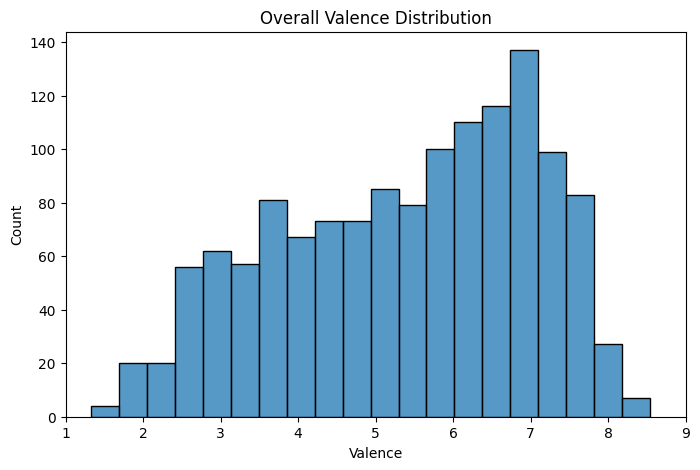

1.00–1.50: 1
1.50–2.00: 21
2.00–2.50: 38
2.50–3.00: 71
3.00–3.50: 88
3.50–4.00: 109
4.00–4.50: 91
4.50–5.00: 106
5.00–5.50: 120
5.50–6.00: 126
6.00–6.50: 157
6.50–7.00: 171
7.00–7.50: 152
7.50–8.00: 89
8.00–8.50: 15
8.50–9.00: 1


In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df_all_naps_ratings["Valence"], bins=20)
plt.xlim(1,9)
plt.xlabel("Valence")
plt.ylabel("Count")
plt.title("All Naps ratings Valence Distribution")
plt.show()

bins = np.linspace(1, 9, 17)  # 16 bins → 17 edges
counts, edges = np.histogram(df_all_naps_ratings["Valence"], bins=bins)
for i in range(len(counts)):
    print(f"{edges[i]:.2f}–{edges[i+1]:.2f}: {counts[i]}")

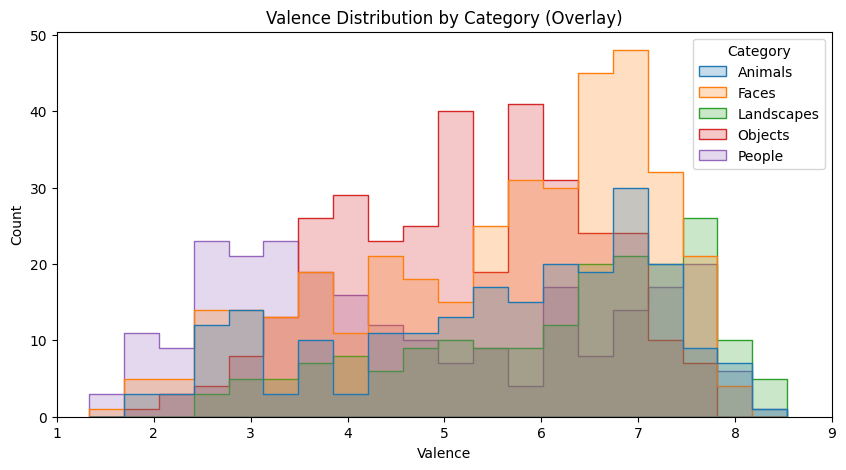

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_all_naps_ratings, x="Valence", hue="Category", bins=20, element="step")
plt.xlim(1,9)
plt.title("Valence Distribution by Category (Overlay)")
plt.show()

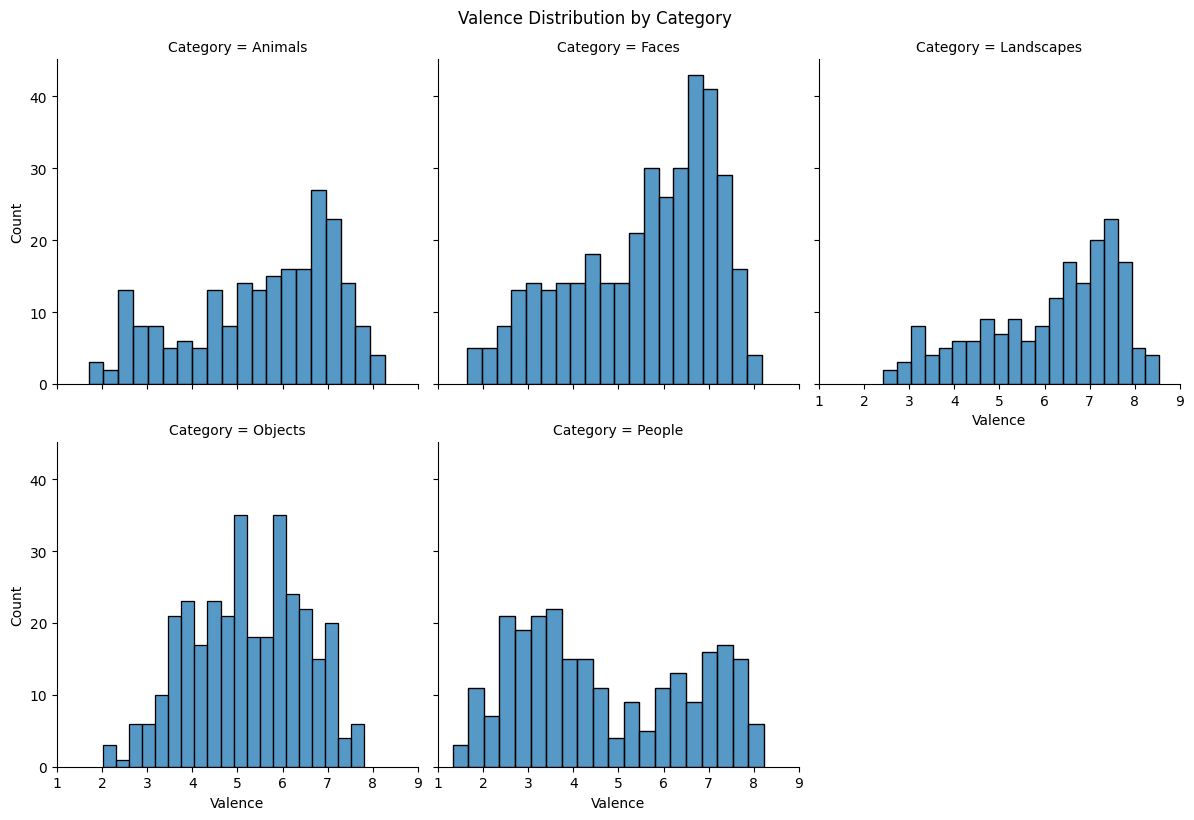

In [19]:
g = sns.FacetGrid(df_all_naps_ratings, col="Category", col_wrap=3, height=4)
g.map_dataframe(sns.histplot, x="Valence", bins=20)
g.set(xlim=(1,9))
g.fig.suptitle("Valence Distribution by Category", y=1.02)
plt.show()

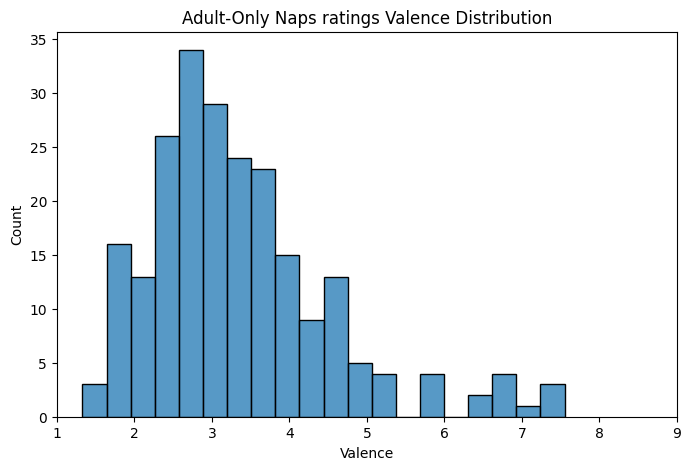

1.00–1.50: 1
1.50–2.00: 21
2.00–2.50: 38
2.50–3.00: 71
3.00–3.50: 88
3.50–4.00: 109
4.00–4.50: 91
4.50–5.00: 106
5.00–5.50: 120
5.50–6.00: 126
6.00–6.50: 157
6.50–7.00: 171
7.00–7.50: 152
7.50–8.00: 89
8.00–8.50: 15
8.50–9.00: 1


In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df_all_naps_ratings[df_all_naps_ratings["ID"].isin(adult_only_naps)]["Valence"], bins=20)
plt.xlim(1,9)
plt.xlabel("Valence")
plt.ylabel("Count")
plt.title("Adult-Only Naps ratings Valence Distribution")
plt.show()

bins = np.linspace(1, 9, 17)  # 16 bins → 17 edges
counts, edges = np.histogram(df_all_naps_ratings["Valence"], bins=bins)
for i in range(len(counts)):
    print(f"{edges[i]:.2f}–{edges[i+1]:.2f}: {counts[i]}")

In [20]:
bins = np.linspace(1, 9, 17)  # 16 bins → 17 edges
counts, edges = np.histogram(df_child_rated_naps["Valence"], bins=bins)
for i in range(len(counts)):
    print(f"{edges[i]:.2f}–{edges[i+1]:.2f}: {counts[i]}")

1.00–1.50: 0
1.50–2.00: 0
2.00–2.50: 9
2.50–3.00: 20
3.00–3.50: 45
3.50–4.00: 77
4.00–4.50: 71
4.50–5.00: 94
5.00–5.50: 115
5.50–6.00: 122
6.00–6.50: 156
6.50–7.00: 166
7.00–7.50: 149
7.50–8.00: 88
8.00–8.50: 15
8.50–9.00: 1


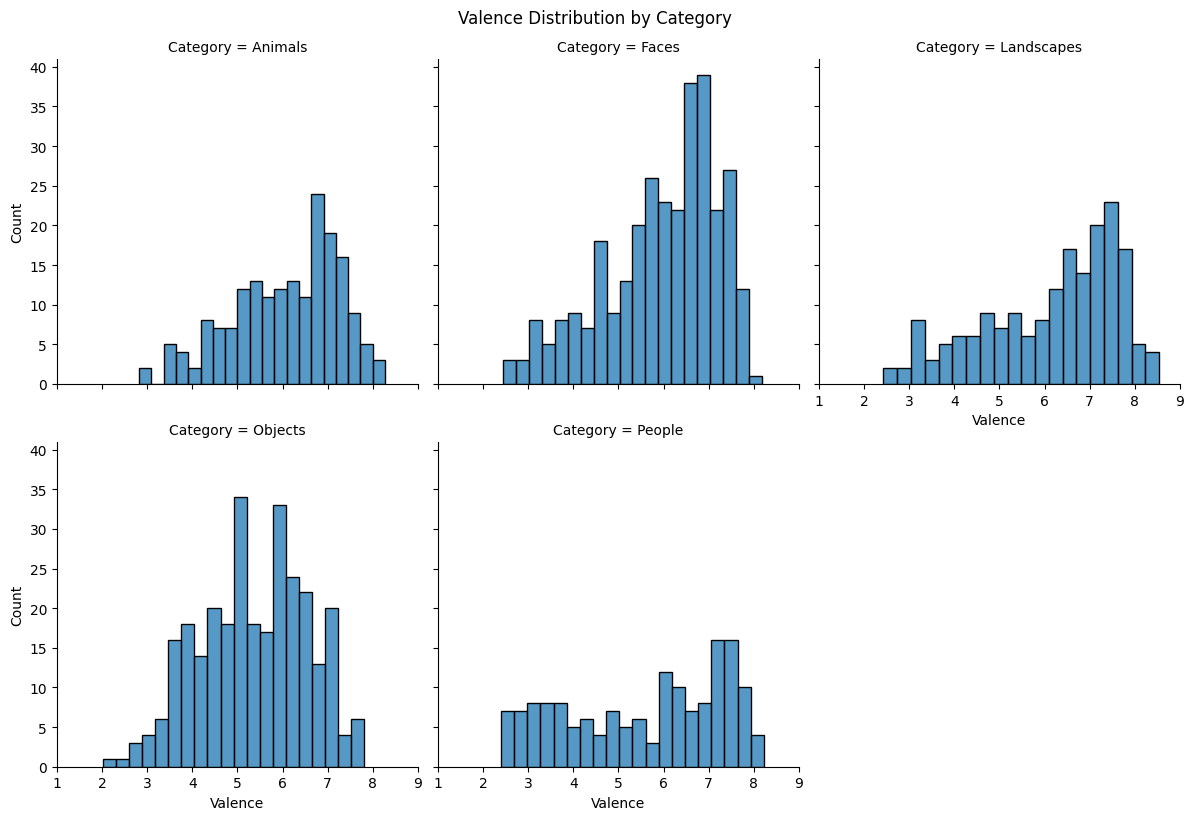

In [14]:
g = sns.FacetGrid(df_child_rated_naps, col="Category", col_wrap=3, height=4)
g.map_dataframe(sns.histplot, x="Valence", bins=20)
g.set(xlim=(1,9))
g.fig.suptitle("Valence Distribution by Category", y=1.02)
plt.show()

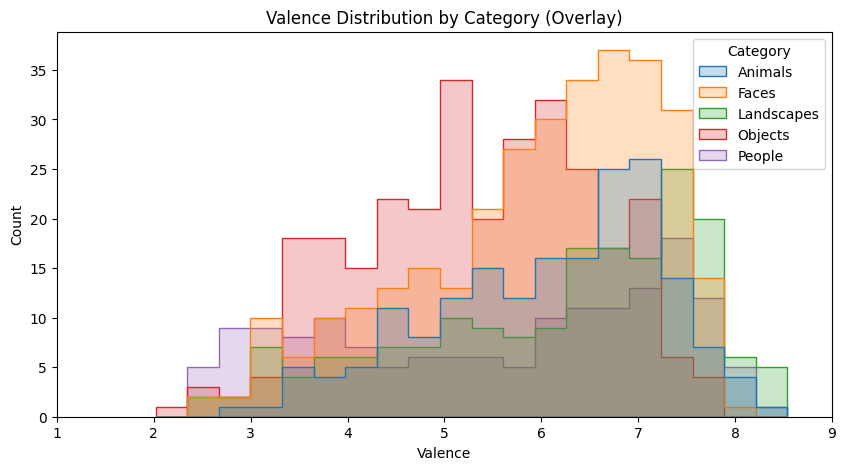

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_child_rated_naps, x="Valence", hue="Category", bins=20, element="step")
plt.xlim(1,9)
plt.title("Valence Distribution by Category (Overlay)")
plt.show()